<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/13%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Decision Tree Classifier Performance ===
Accuracy: 0.633

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      0.90      0.95        10
  versicolor       0.40      0.44      0.42         9
   virginica       0.55      0.55      0.55        11

    accuracy                           0.63        30
   macro avg       0.65      0.63      0.64        30
weighted avg       0.65      0.63      0.64        30



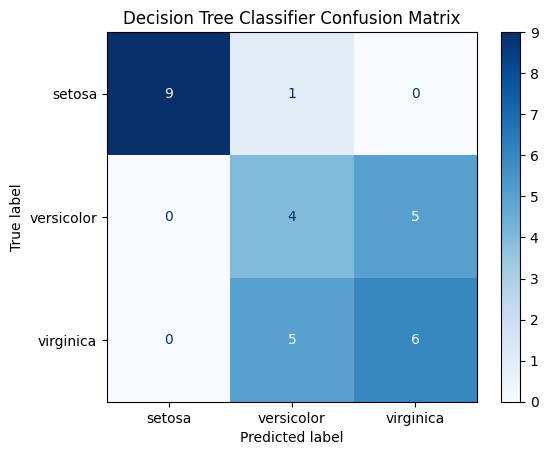

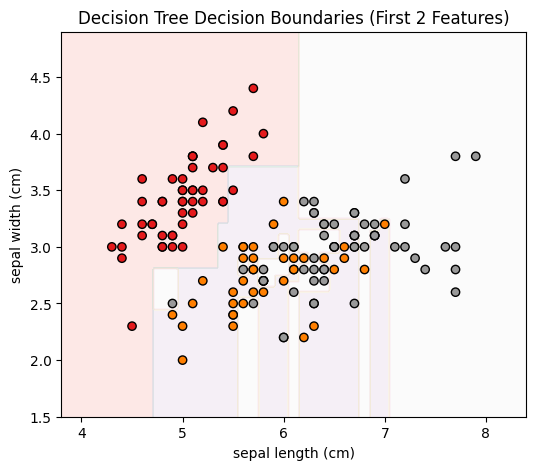

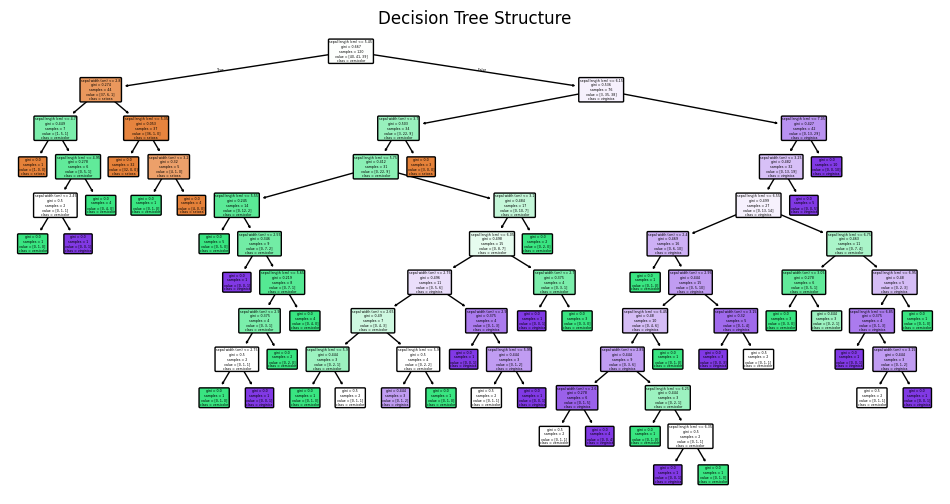

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1️⃣ Choose dataset
# data = load_breast_cancer()  # Binary classification
data = load_iris()             # Multi-class classification

X = data.data[:, :2]  # Use first 2 features for visualization
y = data.target

# 2️⃣ Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3️⃣ Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 4️⃣ Predict
y_pred = dt_model.predict(X_test)

# 5️⃣ Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
print("=== Decision Tree Classifier Performance ===")
print(f"Accuracy: {accuracy:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 6️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()

# 7️⃣ Visualize Decision Boundaries (first 2 features)
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = dt_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Pastel1)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Set1)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Decision Tree Decision Boundaries (First 2 Features)")
plt.show()

# 8️⃣ Optional: Visualize the Tree Structure
plt.figure(figsize=(12,6))
plot_tree(dt_model, feature_names=data.feature_names[:2], class_names=data.target_names,
          filled=True, rounded=True)
plt.title("Decision Tree Structure")
plt.show()
